### A simple example of GMV lensing estimator normalization calculation
This code compute normalization of quadratic estiamtors

In [1]:
# external
import numpy as np, sys
from matplotlib.pyplot import *

In [2]:
# import tempura
import pytempura as tempura

First define parameters

In [3]:
Tcmb  = 2.726e6    # CMB temperature
Lmax  = 3000       # maximum multipole of output normalization
lmax  = 3000
rlmin, rlmax = 2, 3000  # CMB multipole range for reconstruction
nsidet = 2048
L = np.linspace(0,Lmax,Lmax+1)
l = L.copy()
Lfac = (L*(L+1.))**2/(2*np.pi)

Load arrays of lensed CMB Cls. The Cls should not be multiplied by any factors and should not have units.  

In [4]:
lcl = np.zeros((4,lmax+1)) # TT, EE, BB, TE
lcl[:,2:] = np.loadtxt('data/lensedcls.dat',unpack=True,usecols=(1,2,3,4))[:,:lmax-1] 
lcl *= 2.*np.pi / (l**2+l+1e-30) / Tcmb**2

Example noise spectrum

In [5]:
nl = np.zeros((4,lmax+1)) # TT, EE, BB, TE
theta = 1.4*np.pi/10800.
sigma = 8.*np.pi/10800
nl[0] = (sigma/Tcmb)**2*np.exp(l*(l+1)*theta**2/(8.*np.log(2.)))
nl[1] = nl[0]*2.
nl[2] = nl[0]*2.

Define observed CMB cls. Here, no CMB noise.

In [6]:
ocl = lcl+nl # observed Cl

### Compute normalization

QDO below specifies which normalizations will be computed: TT, TE, EE, TB, EB, BB (currently BB is ignored even if you set True)

MV is also automatically computed from these specified estimators

In [7]:
# HOMV normalization
QDO = [True,True,True,True,True,False] # this means that TT, TE, EE, TB and EB are used for MV estimator
Ag, Ac, __, __ = tempura.norm_lens.qall(QDO,Lmax,rlmin,rlmax,lcl,lcl,ocl)

In [8]:
# GMV normalization
ag, ac = tempura.norm_lens.qgmv(Lmax,rlmin,rlmax,lcl,lcl,ocl)

 norm qGMV


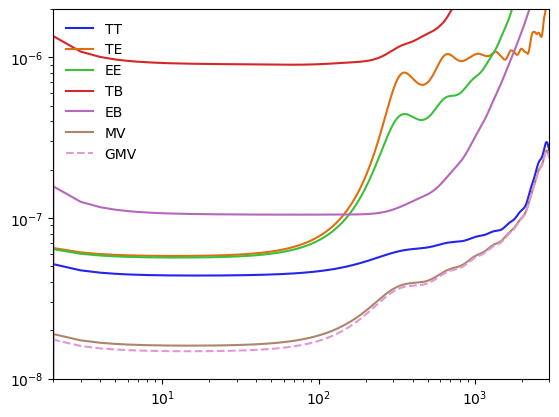

In [9]:
# plot spectra (gradient)
xlim(2,Lmax)
ylim(1e-8,2e-6)
xscale('log')
yscale('log')
for i, q in enumerate(['TT','TE','EE','TB','EB','MV']):
    plot(L,Lfac*Ag[i],label=q)
plot(L,Lfac*ag[5],label='GMV',ls='--')
legend()

/tmp/ipykernel_729449/3762504113.py:4: RuntimeWarning: invalid value encountered in divide
  plot(L,ag[5]/Ag[5])


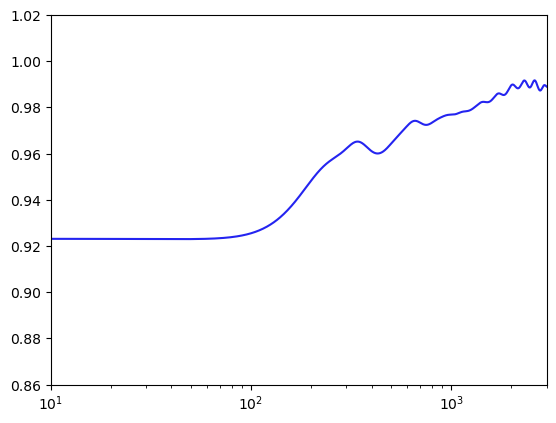

In [10]:
xscale('log')
xlim(10,3000)
ylim(0.86,1.02)
plot(L,ag[5]/Ag[5])

Next, check with simulation

In [11]:
from cmblensplus import curvedsky as cs

In [12]:
# CMB signal
iTalm, iEalm, iBalm = cs.utils.gaussTEB(lcl[0,:],lcl[1,:],lcl[2,:],lcl[3,:])

In [13]:
# CMB noise
nTalm, nEalm, nBalm = cs.utils.gaussTEB(nl[0,:],nl[1,:],nl[2,:],lcl[3,:]*0)

In [14]:
# observed CMB multipoles
oTalm = iTalm + nTalm
oEalm = iEalm + nEalm
oBalm = iBalm + nBalm

In [15]:
# modified diagonal filter for GMV
tcl = ocl.copy()
for l in range(rlmin,rlmax+1):
    rhosq = ocl[3,l]**2/(ocl[0,l]*ocl[1,l]) # rho^2 = TE^2/(TT*EE)
    tcl[0,l] = ocl[0,l]*(1.-rhosq) # TT
    tcl[1,l] = ocl[1,l]*(1.-rhosq) # EE
    tcl[3,l] = ocl[3,l]*(1.-1./rhosq) # TE

In [16]:
Fl = np.zeros((4,rlmax+1,rlmax+1)) # the first index means 0=T, 1=E, 2=B
for l in range(rlmin,rlmax+1):
    Fl[:,l,0:l+1] = 1./tcl[:4,l,None]

In [17]:
# multiply filter to alms
Talm = Fl[0,:,:]*oTalm + Fl[3,:,:]*oEalm
Ealm = Fl[1,:,:]*oEalm + Fl[3,:,:]*oTalm
Balm = Fl[2,:,:]*oBalm

In [18]:
glm, clm = {}, {}
print('TT')
glm['TT'], clm['TT'] = cs.rec_lens.qtt(Lmax,rlmin,rlmax,lcl[0,:],Talm,Talm,nside_t=nsidet)
print('TE')
glm['TE'], clm['TE'] = cs.rec_lens.qte(Lmax,rlmin,rlmax,lcl[3,:],Talm,Ealm,nside_t=nsidet)
print('EE')
glm['EE'], clm['EE'] = cs.rec_lens.qee(Lmax,rlmin,rlmax,lcl[1,:],Ealm,Ealm,nside_t=nsidet)
print('TB')
glm['TB'], clm['TB'] = cs.rec_lens.qtb(Lmax,rlmin,rlmax,lcl[3,:],Talm,Balm,nside_t=nsidet)
print('EB')
glm['EB'], clm['EB'] = cs.rec_lens.qeb(Lmax,rlmin,rlmax,lcl[1,:],Ealm,Balm,nside_t=nsidet)

TT
TE
EE
TB
EB


In [19]:
Glm, Clm = {}, {}
for qi, q in enumerate(['TT','TE','EE','TB','EB']):
    Glm[q] = ag[qi,:,None]*glm[q]
    Clm[q] = ac[qi,:,None]*clm[q]
Glm['GMV'], Clm['GMV'] = 0., 0.
for qi, q in enumerate(['TT','TE','EE','TB','EB']):
    Glm['GMV'] += glm[q]
    Clm['GMV'] += clm[q]
Glm['GMV'] *= ag[5,:,None]
Clm['GMV'] *= ac[5,:,None]

In [20]:
GG, CC = {}, {}
for q in ['TT','TE','EE','TB','EB','GMV']:
    GG[q] = cs.utils.alm2cl(Glm[q])
    CC[q] = cs.utils.alm2cl(Clm[q])

In [21]:
import plottools as pl

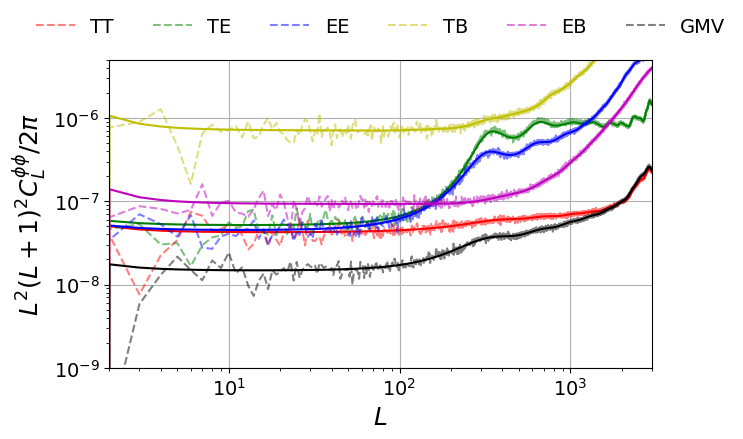

In [22]:
# plot spectra (gradient)
pl.plot_1dstyle(fsize=[7,4],xmin=2,xmax=Lmax,xlog=True,ylog=True,ymin=1e-9,ymax=5e-6,grid=True,ylab=r'$L^2(L+1)^2C^{\phi\phi}_L/2\pi$')
for qi, (c, q) in enumerate([('r','TT'),('g','TE'),('b','EE'),('y','TB'),('m','EB'),('k','GMV')]):
    plot(L,Lfac*GG[q],color=c,ls='--',label=q,alpha=.5)
    plot(L,Lfac*ag[qi,:],color=c,ls='-')
legend(loc="lower center",bbox_to_anchor=(0.5, 1.02),ncols=6)

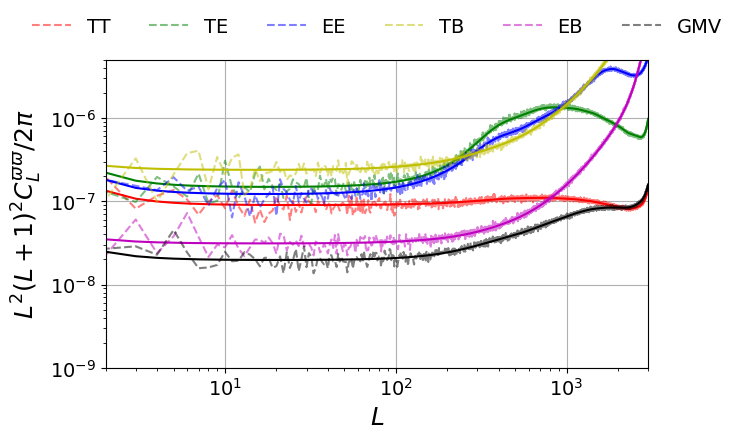

In [23]:
pl.plot_1dstyle(fsize=[7,4],xmin=2,xmax=Lmax,xlog=True,ylog=True,ymin=1e-9,ymax=5e-6,grid=True,ylab=r'$L^2(L+1)^2C^{\varpi\varpi}_L/2\pi$')
for qi, (c, q) in enumerate([('r','TT'),('g','TE'),('b','EE'),('y','TB'),('m','EB'),('k','GMV')]):
    plot(L,Lfac*CC[q],color=c,ls='--',label=q,alpha=.5)
    plot(L,Lfac*ac[qi,:],color=c,ls='-')
legend(loc="lower center",bbox_to_anchor=(0.5, 1.02),ncols=6)

In [24]:
ag, ac = tempura.norm_lens.qgmv(Lmax,rlmin,rlmax,lcl,lcl,ocl,th_vary=True)

 norm qGMV


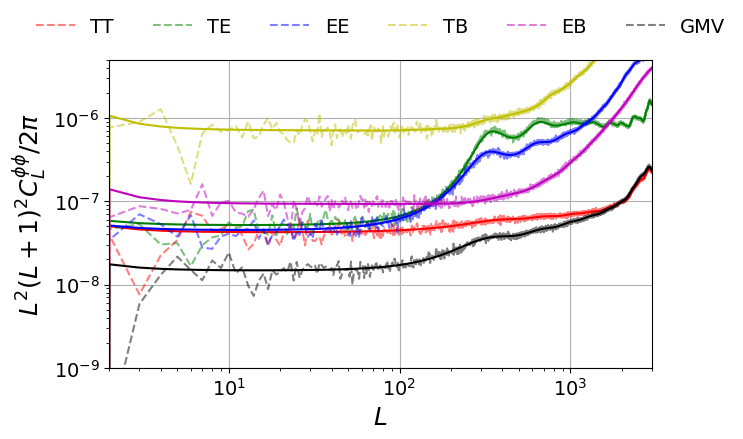

In [25]:
# plot spectra (gradient)
pl.plot_1dstyle(fsize=[7,4],xmin=2,xmax=Lmax,xlog=True,ylog=True,ymin=1e-9,ymax=5e-6,grid=True,ylab=r'$L^2(L+1)^2C^{\phi\phi}_L/2\pi$')
for qi, (c, q) in enumerate([('r','TT'),('g','TE'),('b','EE'),('y','TB'),('m','EB'),('k','GMV')]):
    plot(L,Lfac*GG[q],color=c,ls='--',label=q,alpha=.5)
    plot(L,Lfac*ag[qi,:],color=c,ls='-')
legend(loc="lower center",bbox_to_anchor=(0.5, 1.02),ncols=6)

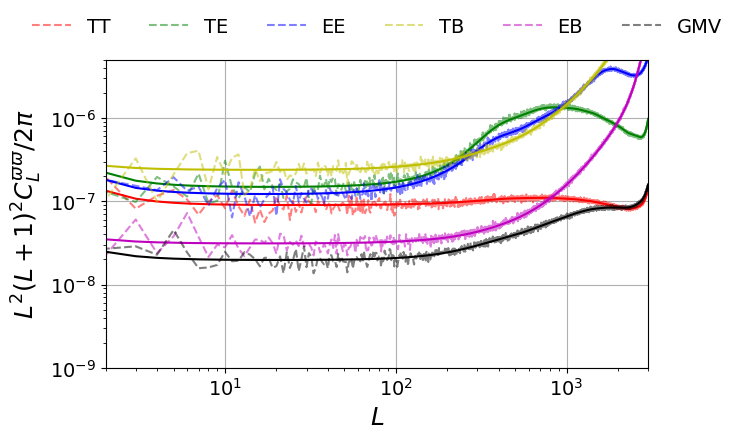

In [26]:
pl.plot_1dstyle(fsize=[7,4],xmin=2,xmax=Lmax,xlog=True,ylog=True,ymin=1e-9,ymax=5e-6,grid=True,ylab=r'$L^2(L+1)^2C^{\varpi\varpi}_L/2\pi$')
for qi, (c, q) in enumerate([('r','TT'),('g','TE'),('b','EE'),('y','TB'),('m','EB'),('k','GMV')]):
    plot(L,Lfac*CC[q],color=c,ls='--',label=q,alpha=.5)
    plot(L,Lfac*ac[qi,:],color=c,ls='-')
legend(loc="lower center",bbox_to_anchor=(0.5, 1.02),ncols=6)